# V3 empirical study — 1.5-year monthly calibration — option-implied Heston family

**This notebook is the computational source of truth.** The PDF in this folder is written from the same `payload` dict, so every table number matches.

| Item | Setting |
|------|---------|
| Models | Heston, Heston–Merton |
| Companies | SPY (primary), AAPL, MSFT, AMZN |
| Regimes | Crisis 2008-08-01→2009-07-31 · Normal 2014-01-01→2014-12-31 · Late-cycle 2018-10-01→2019-09-30 · COVID 2019-09-01→2020-08-31 |
| Calibration | **1.5-year** lookback, **monthly** recalibration |
| Primary metric | Percentage RMSE |
| Secondary | MAE, Bias $ (model − market), Bias%, Early-exercise fraction |
| Paths | LSM American calls, `n_paths=10000`, `seed=42` |
| Code | V3 notebooks + `option_filters.py` + Euler-corrected Heston step |

In every table the **BEST** model is the lowest RMSE%. That row is **bold and green**.


## 0. Methodology and conditions

### No look-ahead
At monthly update t, parameters use only returns and listed quotes with `trading_date ≤ t`. LSM prices a Monday contract with the latest calibration row dated on or before that Monday. Option quotes are as-of the grid timestamp (same session, else the prior session).

### Shared sample (no model-specific data selection)
For each company × regime the Monday nearest-ATM listed-call sample is drawn **once** and passed to all two models in this report. Filters, testing dates, simulation settings, and the market benchmark are therefore identical.

### Filters (applied in this order)
1. Calls only; finite S, K, C.
2. No-arbitrage: C ≥ max(0, S−K).
3. Maturity: 7 ≤ DTE ≤ 60.
4. Moneyness: |S/K − 1| ≤ 10%.
5. Liquidity: premium ≥ 0.05; valid bid–ask and relative spread ≤ 50% when those columns exist; volume ≥ 1 when present.

### Metrics
- Primary: RMSE%.
- Secondary: MAE (dollars), Bias $ = mean(model − market), **Bias% = 100 × mean((model − market)/market)**, early-exercise fraction.
- Ranking uses RMSE% only. The dollar bias column is kept; Bias% is the scale-free companion.

### Model-correctness adjustments
- Heston / Heston–Merton: option-implied Fourier NLS for (κ, θ, ξ, ρ, v0). Not Method A.
- Euler: stock return over [t, t+Δt] uses **current** v_t; then update v_{t+Δt}.
- LSM never averages paths before stopping.

### Data limits
Equity adj-close starts **2003-12-01**. Listed-option panels start **2008-01**. Estimators use all available history when the requested lookback is longer than the file.

### Re-run
This notebook is a grouped companion. It loads stored cells and does **not** re-run LSM. To rebuild only this group's PDF/notebook, call `groups.write_group(...)`. Do not set RECOMPUTE on the six-model engine; that would overwrite the original study files.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML, Markdown, Image
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('option_implied')
print('cells', len(payload['cells']), 'models', payload['meta']['models'])
# Rebuild this group's PDF/notebook only (does not overwrite the six-model study):
# groups.write_group('option_implied')

## 1. Shared evaluation sample


In [1]:
from IPython.display import HTML, display
rows = ['<h4>n contracts (identical across models)</h4>']
display(HTML(''.join(study._html_table(payload['tables'][k]) if False else '')))
meta = payload['shared_contracts']
import pandas as pd
df = pd.DataFrame([{ 'regime': r, **meta[r]['n'], 'start': meta[r]['period_start'], 'end': meta[r]['period_end']} for r in study.REGIME_ORDER])
display(df)

Regime,Window,SPY,AAPL,MSFT,AMZN
2008-2009 Crisis,2008-08-01 → 2009-07-31,50,50,50,50
2013-2014 Normal,2014-01-01 → 2014-12-31,50,50,50,50
2018-2019 Late-cycle,2018-10-01 → 2019-09-30,50,51,50,51
2019-2020 COVID,2019-09-01 → 2020-08-31,50,50,50,50


## 2.1 Detailed tables — `SPY`


### Table SPY-1. SPY · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,32.75,1.0960,+0.5803,+20.80,26.9%,2
Heston–Merton,31.60,1.0435,+0.5375,+19.11,21.4%,1


### Table SPY-2. SPY · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,52.46,1.0201,+0.9451,+42.44,26.9%,1
Heston–Merton,67.16,1.2748,+1.2103,+53.41,24.5%,2


### Table SPY-3. SPY · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,73.93,2.3623,+2.1183,+54.85,22.3%,1
Heston–Merton,84.01,2.7641,+2.5349,+64.41,17.0%,2


### Table SPY-4. SPY · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,65.44,3.7704,+2.6179,+50.30,26.4%,1
Heston–Merton,66.64,3.5171,+2.3874,+47.68,15.7%,2


## 2.2 Detailed tables — Company summary


Same four-regime layout as SPY. Each value is the arithmetic mean of **AAPL, MSFT, AMZN**. Ranking uses mean RMSE%.


### Table Co-1. Company summary · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Heston** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2008-2009', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,29.18,0.9812,+0.6597,+18.06,24.1%,1
Heston–Merton,29.62,0.9867,+0.6635,+18.32,17.9%,2


### Table Co-2. Company summary · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Heston–Merton** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2013-2014', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,36.31,2.0299,+1.8887,+26.42,21.7%,2
Heston–Merton,32.05,1.7232,+1.5304,+20.94,14.7%,1


### Table Co-3. Company summary · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · mean of AAPL, MSFT, AMZN · n̄ = 51 · **BEST = Heston–Merton** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2018-2019', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,40.44,7.4928,+6.8740,+31.55,21.1%,2
Heston–Merton,37.27,6.7082,+5.8681,+26.30,16.8%,1


### Table Co-4. Company summary · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Heston–Merton** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2019-2020', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,42.95,11.7492,+7.8777,+31.35,22.9%,2
Heston–Merton,40.20,11.3578,+7.0705,+25.96,16.7%,1


## 2.3 Detailed tables — `AAPL`


### Table AAPL-1. AAPL · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,31.71,1.5996,+1.0721,+21.09,22.7%,1
Heston–Merton,32.30,1.6138,+1.0704,+21.37,18.5%,2


### Table AAPL-2. AAPL · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,37.85,2.5745,+2.5702,+29.62,20.8%,2
Heston–Merton,31.91,1.9670,+1.9420,+21.53,15.2%,1


### Table AAPL-3. AAPL · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,45.14,2.3820,+2.2976,+38.59,21.0%,2
Heston–Merton,41.69,2.0875,+1.9310,+32.87,18.2%,1


### Table AAPL-4. AAPL · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,42.24,3.7296,+2.9444,+33.15,23.3%,2
Heston–Merton,40.88,3.4396,+2.5150,+30.03,16.7%,1


## 2.4 Detailed tables — `MSFT`


### Table MSFT-1. MSFT · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,26.51,0.2560,+0.0897,+12.61,24.7%,1
Heston–Merton,26.84,0.2552,+0.0910,+12.75,18.6%,2


### Table MSFT-2. MSFT · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,31.79,0.1889,+0.1565,+21.39,22.6%,2
Heston–Merton,26.54,0.1648,+0.1181,+16.70,12.2%,1


### Table MSFT-3. MSFT · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,37.47,0.9577,+0.8192,+26.22,21.8%,2
Heston–Merton,33.23,0.7984,+0.6200,+19.90,16.2%,1


### Table MSFT-4. MSFT · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,40.67,2.0782,+1.5079,+30.43,23.8%,2
Heston–Merton,35.19,1.7711,+1.0681,+20.23,16.0%,1


## 2.5 Detailed tables — `AMZN`


### Table AMZN-1. AMZN · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,29.31,1.0880,+0.8173,+20.47,25.0%,1
Heston–Merton,29.73,1.0912,+0.8291,+20.84,16.5%,2


### Table AMZN-2. AMZN · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,39.29,3.3265,+2.9394,+28.25,21.8%,2
Heston–Merton,37.71,3.0378,+2.5310,+24.58,16.6%,1


### Table AMZN-3. AMZN · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,38.70,19.1386,+17.5052,+29.83,20.5%,2
Heston–Merton,36.89,17.2386,+15.0534,+26.13,16.0%,1


### Table AMZN-4. AMZN · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Heston,45.95,29.4399,+19.1809,+30.46,21.6%,2
Heston–Merton,44.52,28.8627,+17.6284,+27.61,17.3%,1


## 3. Summary tables


### Table S1 — Overall ranking


In [1]:
display(HTML('overall ranking table is rendered from payload["summary_overall"]'))

Rank,Model,Mean RMSE%,Median RMSE%,# cells best
1,Heston–Merton BEST,41.68,36.04,10
2,Heston,41.95,39.00,6


## 4. Figures


### Figure 1 — RMSE% by regime (mean of four companies)


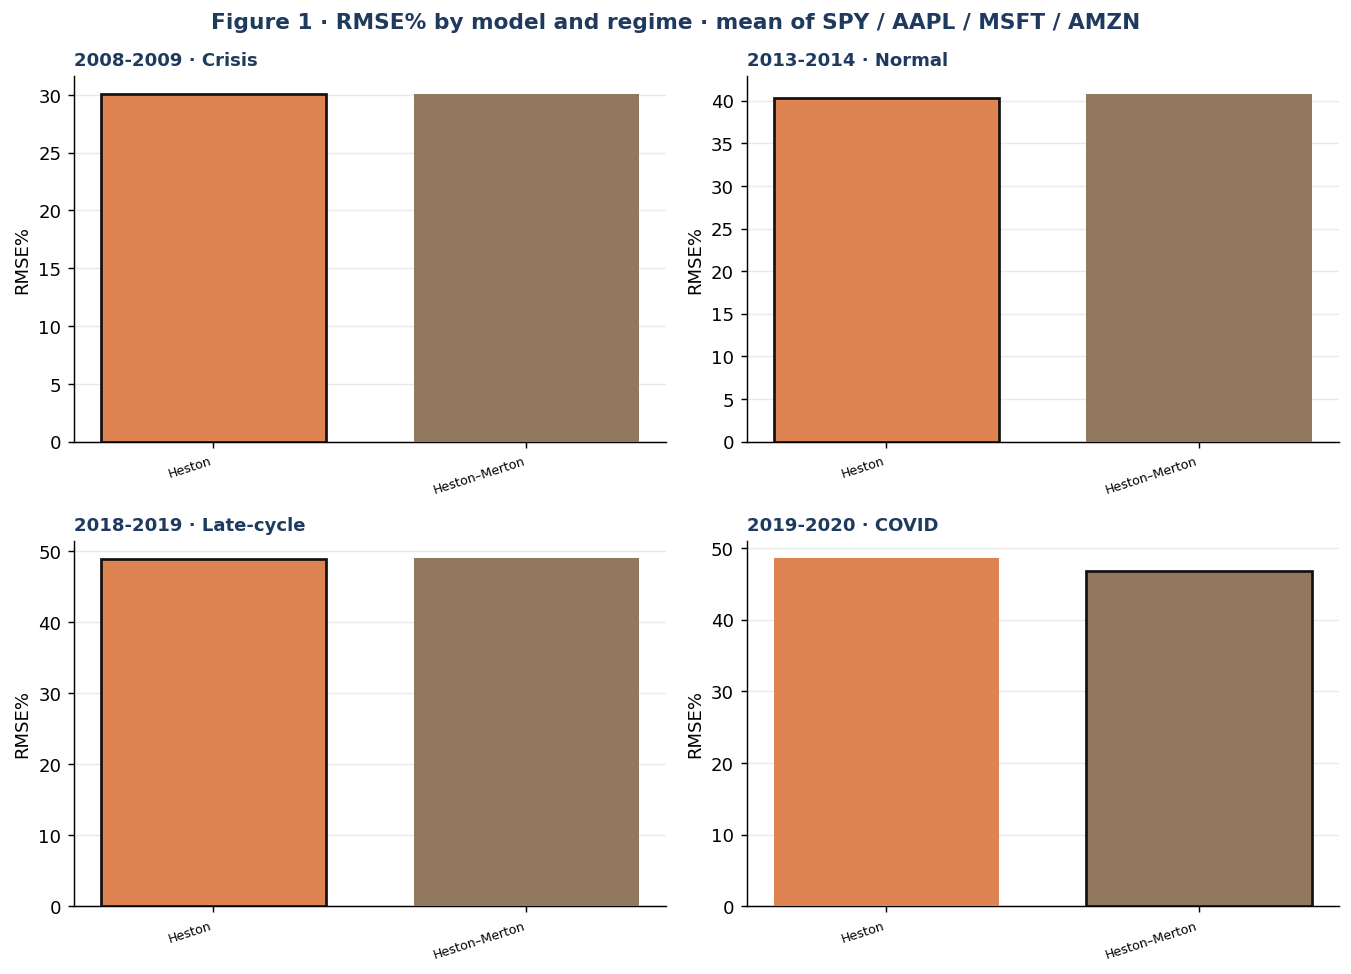

In [1]:
pass  # figure embedded from the same payload used for the PDF

### Figure 2 — RMSE% by company


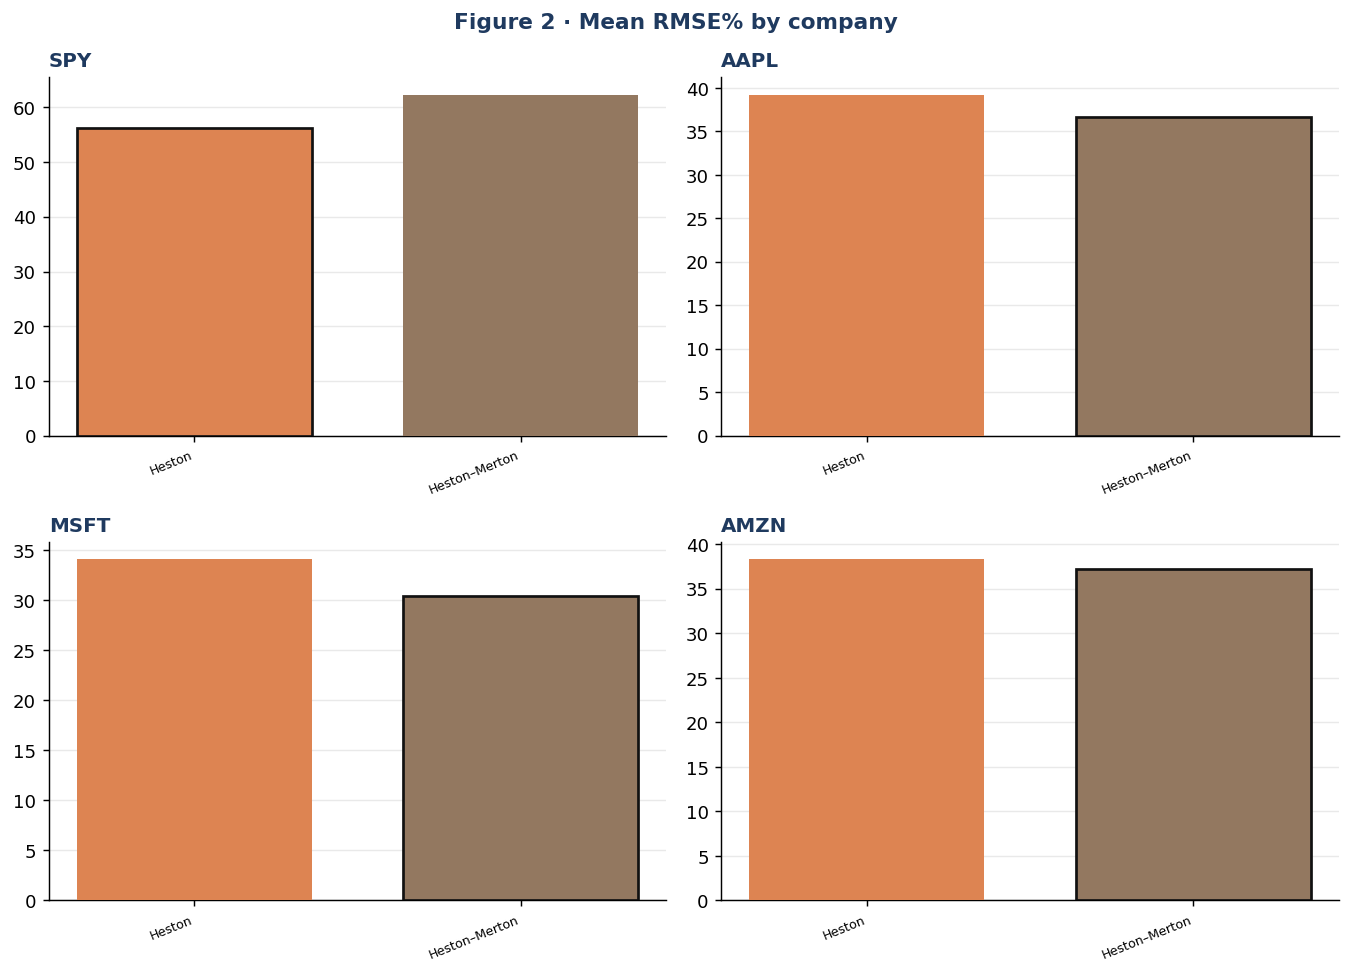

In [1]:
pass

### Figure 3 — Rank heatmap


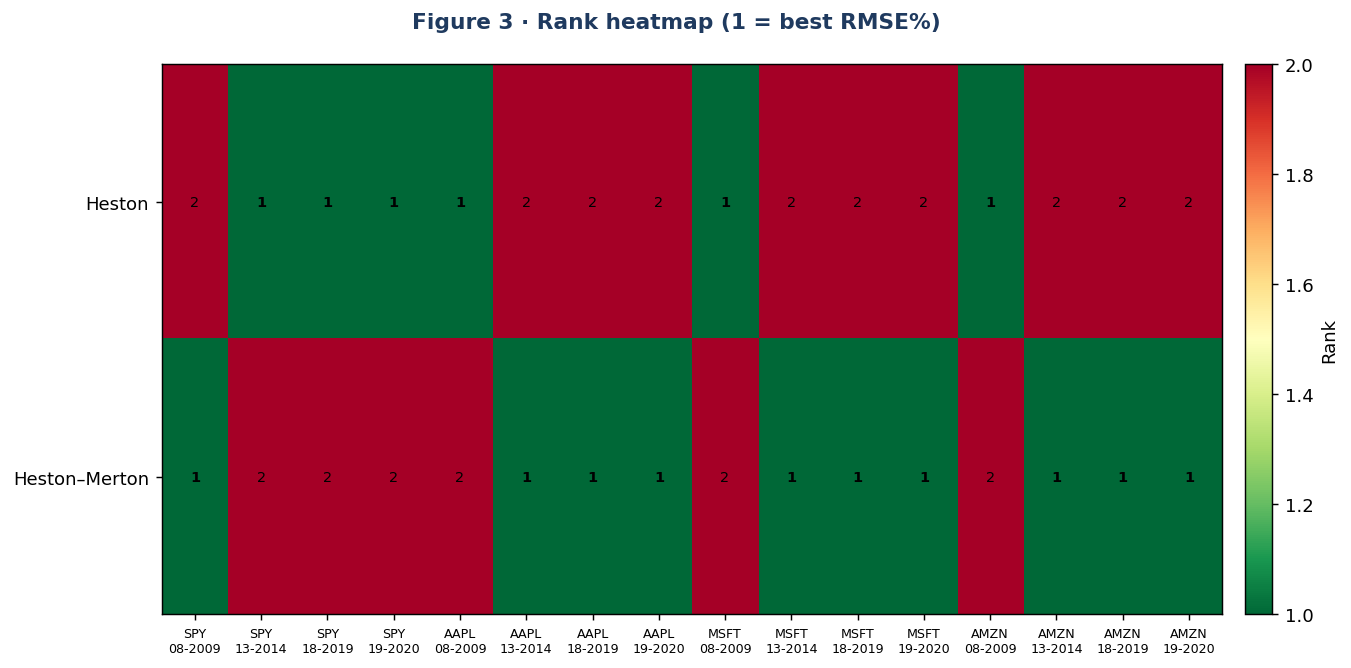

In [1]:
pass

## 5. Final analysis

- On mean percentage RMSE across the 16 company×regime cells, Heston–Merton is the best overall model (mean RMSE% = 41.68; 10 of 16 cells).

- Second overall is Heston (mean RMSE% = 41.95; 6 cells).

- The ranking is not stable. Best-in-cell models across the 16 tables: Heston, Heston–Merton.

- SPY: lowest mean RMSE% is Heston (56.15); wins 3 of 4 regimes.

- AAPL: lowest mean RMSE% is Heston–Merton (36.69); wins 3 of 4 regimes.

- MSFT: lowest mean RMSE% is Heston–Merton (30.45); wins 3 of 4 regimes.

- AMZN: lowest mean RMSE% is Heston–Merton (37.21); wins 3 of 4 regimes.

- 2008-2009 (Crisis): best mean RMSE% is Heston (30.07).

- 2013-2014 (Normal): best mean RMSE% is Heston (40.35).

- 2018-2019 (Late-cycle): best mean RMSE% is Heston (48.81).

- 2019-2020 (COVID): best mean RMSE% is Heston–Merton (46.81).

- Jump models as a group have lower mean RMSE% (41.68) than the no-jump models in this report (41.95).

- For the overall winner (Heston–Merton), crisis RMSE% is 30.12 vs 40.83 in the 2014 normal year — absolute pricing error is regime-dependent even when the ranking is not.

- These conclusions are conditional on the V3 filters, 1.5-year monthly calibration, Monday ATM sample, LSM with 10,000 paths, and American-call quotes only. They are not a statement about European options or other tenors.


## 6. Reproducibility

This grouped report is assembled from the frozen 10,000-path cells. No new calibration or LSM.

```python
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('option_implied')
groups.write_group('option_implied')
```

The original six-model files `V3_1p5y_monthly_empirical_study.pdf` / `.ipynb` are not rewritten.
Partial results remain in `V3-Models_result/results/empirical_study_1p5y_monthly_10000/partial/`.
Shared contracts are frozen in `shared_contracts.json`.
